Se inicia con la implementacion de modelos supervisados, con el objetivo de predecir una variable objetivo a partir de un conjunto de variables predictoras. Este proceso implica la selección y preparación de los datos, la elección del modelo adecuado, el entrenamiento del modelo con los datos de entrenamiento, y la evaluación del rendimiento del modelo utilizando métricas apropiadas. El objetivo final es desarrollar un modelo que pueda generalizar bien a nuevos datos y proporcionar predicciones precisas.

In [1]:
import pandas as pd
from scripts.preprocesamiento import preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Carga de los datos
DF_ORIGINAL = pd.read_csv('..\\..\\data\\raw\\dataset_chile_cancer_piel.csv')

# Crea copia del dataframe para trabajar
df = DF_ORIGINAL.copy()

# Limpieza
df_ready = preprocesamiento(df)

# Definición de X e y (Siguiendo el flujo del docente)
X = df_ready.drop('Antecedentes personales de cáncer', axis=1)
y = df_ready['Antecedentes personales de cáncer']

# División Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ModuleNotFoundError: No module named 'scripts'

In [ ]:
# Modelo 1: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Modelo 2: Support Vector Machine (SVM)
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

print("Modelos entrenados con éxito.")

Modelos entrenados con éxito.


Random Forest: Lo usamos porque es un modelo de ensamble que reduce el riesgo de sobreajuste (overfitting) y nos permite ver qué variables (como la Edad o el Tamaño de la lesión) son más importantes para predecir el cáncer.

SVM: Es excelente cuando los datos no son linealmente separables, usando el "kernel trick" para encontrar un hiperplano que divida a los pacientes con y sin antecedentes.

In [ ]:
# Realizar predicciones con los datos de prueba
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# También es útil predecir probabilidades para métricas como el AUC-ROC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("Predicciones y probabilidades generadas.")

Predicciones y probabilidades generadas.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

# Calcular métricas de evaluación para ambos modelos
metricas = {
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
    },
    'SVM': {
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm),
        'Recall': recall_score(y_test, y_pred_svm),
        'F1-Score': f1_score(y_test, y_pred_svm),
        'ROC-AUC': roc_auc_score(y_test, y_prob_svm)
    }
}

# Mostrar comparativa de métricas
print("=" * 70)
print("COMPARATIVA DE MODELOS")
print("=" * 70)
metricas_df = pd.DataFrame(metricas).round(4)
print(metricas_df)
print("=" * 70)

COMPARATIVA DE MODELOS
           Random Forest     SVM
Accuracy          0.6450  0.6400
Precision         0.6000  0.0000
Recall            0.0417  0.0000
F1-Score          0.0779  0.0000
ROC-AUC           0.5156  0.4806


/home/dani/entornos/Prueba2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


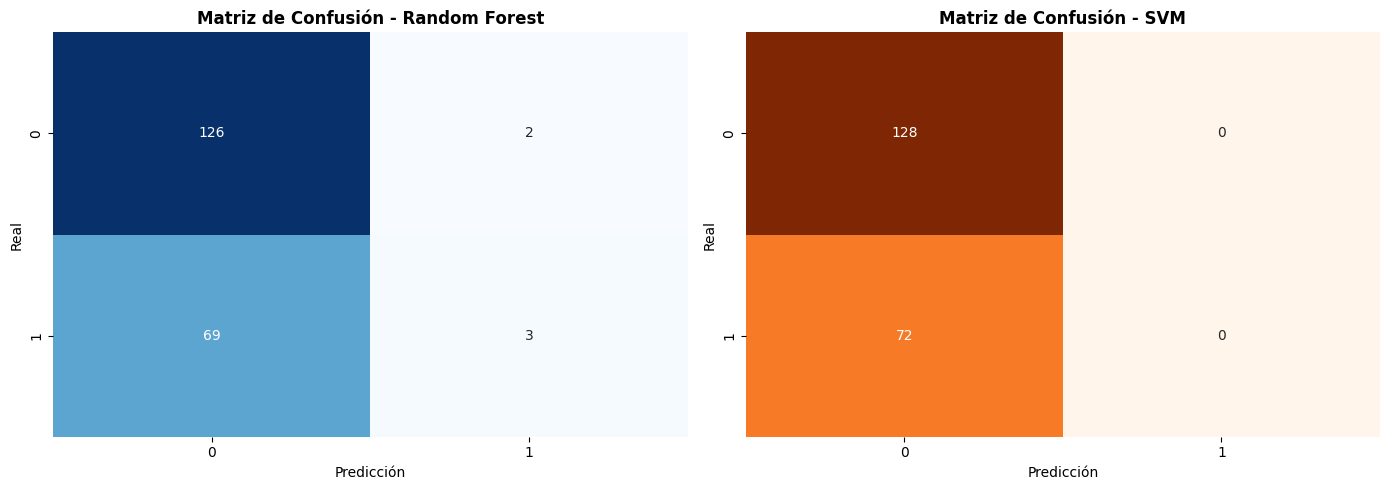


REPORTE DE CLASIFICACIÓN - RANDOM FOREST:
              precision    recall  f1-score   support

           0       0.65      0.98      0.78       128
           1       0.60      0.04      0.08        72

    accuracy                           0.65       200
   macro avg       0.62      0.51      0.43       200
weighted avg       0.63      0.65      0.53       200


REPORTE DE CLASIFICACIÓN - SVM:
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       128
           1       0.00      0.00      0.00        72

    accuracy                           0.64       200
   macro avg       0.32      0.50      0.39       200
weighted avg       0.41      0.64      0.50       200



/home/dani/entornos/Prueba2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dani/entornos/Prueba2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dani/entornos/Prueba2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Crear matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - SVM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("\nREPORTE DE CLASIFICACIÓN - RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf))
print("\nREPORTE DE CLASIFICACIÓN - SVM:")
print(classification_report(y_test, y_pred_svm))

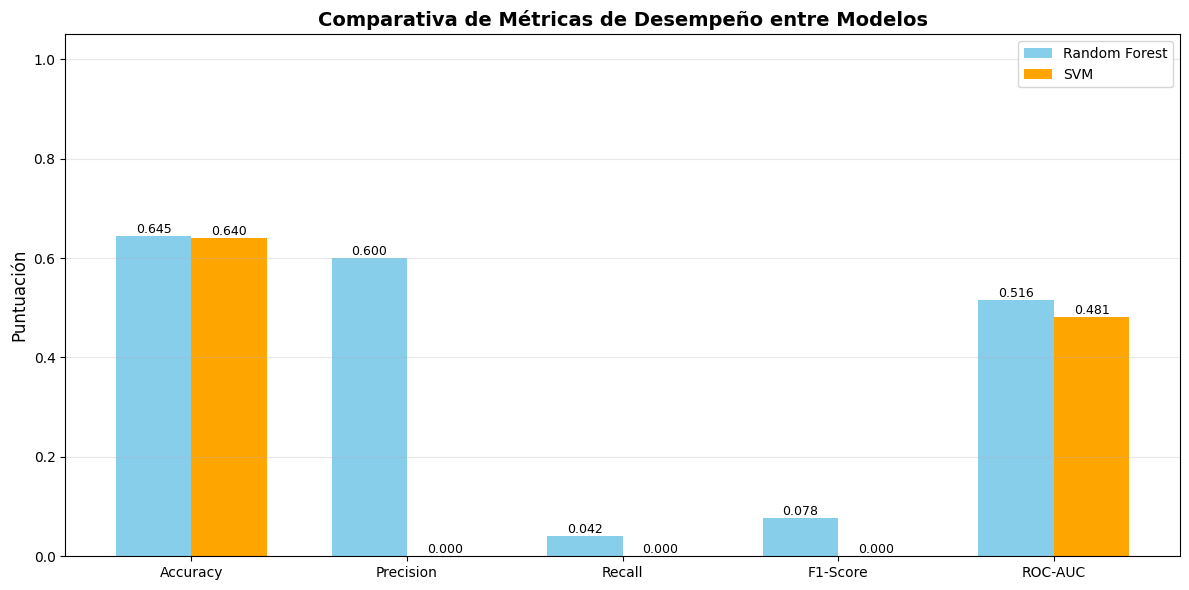


CONCLUSIÓN:
El modelo Random Forest presenta mejor rendimiento general (F1-Score: 0.0779)


In [ ]:
# Comparativa visual de métricas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metricas_df.index))
width = 0.35

bars1 = ax.bar(x - width/2, metricas_df['Random Forest'], width, label='Random Forest', color='skyblue')
bars2 = ax.bar(x + width/2, metricas_df['SVM'], width, label='SVM', color='orange')

ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparativa de Métricas de Desempeño entre Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_df.index)
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN:")
rf_score = metricas_df.loc['F1-Score', 'Random Forest']
svm_score = metricas_df.loc['F1-Score', 'SVM']
mejor_modelo = 'Random Forest' if rf_score > svm_score else 'SVM'
print(f"El modelo {mejor_modelo} presenta mejor rendimiento general (F1-Score: {max(rf_score, svm_score):.4f})")

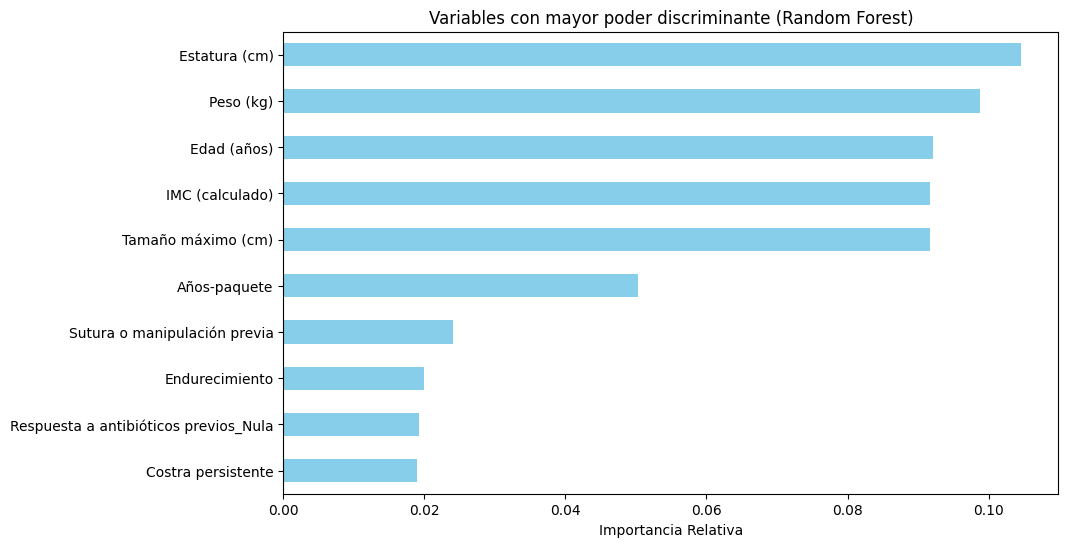

In [ ]:
import matplotlib.pyplot as plt

# Extraer importancia del Random Forest
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)

# Graficar las 10 más relevantes
plt.figure(figsize=(10, 6))
importancias.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Variables con mayor poder discriminante (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

In [ ]:
import joblib
import os

# Crear carpeta de modelos si no existe
os.makedirs('models', exist_ok=True)

# Guardar modelos
joblib.dump(rf_model, 'models/rf_model_base.pkl')
joblib.dump(svm_model, 'models/svm_model_base.pkl')

# Guardar los datos de prueba para que el notebook 03 los evalúe exactamente igual
test_data = {'X_test': X_test, 'y_test': y_test, 'y_pred_rf': y_pred_rf, 'y_pred_svm': y_pred_svm}
joblib.dump(test_data, 'models/test_data_eval.pkl')

print("Modelos y datos de prueba guardados exitosamente.")

Modelos y datos de prueba guardados exitosamente.
